In [1]:
import pandas as pd
import glob
import os
import warnings

warnings.filterwarnings("ignore")

In [2]:


# Define folder path
folder_path = "units/cume_units.xlsx"


# Read all files into DataFrames and add filename column
df = pd.read_excel(folder_path, skiprows=2)



In [3]:
folder_path = "units/cume_revenues.xlsx"


revs  = pd.read_excel(folder_path, skiprows=2)


In [4]:
folder_path = "wishlists/Annapurna Interactive Historical Revenues - releases_dates.csv"
dates  = pd.read_csv(folder_path)
dates = dates.dropna(subset='pc_release_date')
dates['pc_release_date'] = pd.to_datetime(dates['pc_release_date'])
release_date_dict = dates.groupby('product')['pc_release_date'].min().to_dict()

In [5]:
df.query("product =='to a T'")

,Date,product,Cumulative Selected Measure
100535,2025-05-28,to a T,2251
100607,2025-05-29,to a T,3417
100679,2025-05-30,to a T,4121
100751,2025-05-31,to a T,4624
100823,2025-06-01,to a T,4978
100895,2025-06-02,to a T,5187
100967,2025-06-03,to a T,5187


In [6]:
revs

,Date,product,Cumulative Selected Measure
0,2017-03-14,What Remains of Edith Finch,2673.49
1,2017-03-15,What Remains of Edith Finch,7086.67
2,2017-03-16,What Remains of Edith Finch,9976.77
3,2017-03-17,What Remains of Edith Finch,11789.20
4,2017-03-18,What Remains of Edith Finch,14156.59
...,...,...,...
100971,2025-06-03,Wanderstop - Soundtrack,16793.77
100972,2025-06-03,Wattam,1071772.69
100973,2025-06-03,Wattam - Original Soundtrack,4905.52
100974,2025-06-03,What Remains of Edith Finch,19812886.21


In [7]:
df = df.rename({"Cumulative Selected Measure":"units"}, axis=1)

In [8]:
df["percent_of_max"] = df["units"] / df.groupby("product")["units"].transform("max")

In [9]:
df

,Date,product,units,percent_of_max
0,2017-03-14,What Remains of Edith Finch,165,0.000065
1,2017-03-15,What Remains of Edith Finch,438,0.000172
2,2017-03-16,What Remains of Edith Finch,614,0.000241
3,2017-03-17,What Remains of Edith Finch,726,0.000285
4,2017-03-18,What Remains of Edith Finch,871,0.000342
...,...,...,...,...
100971,2025-06-03,Wanderstop - Soundtrack,2268,1.000000
100972,2025-06-03,Wattam,93199,1.000000
100973,2025-06-03,Wattam - Original Soundtrack,1040,1.000000
100974,2025-06-03,What Remains of Edith Finch,2545540,1.000000


In [10]:
df.drop_duplicates(subset='product', keep='last').tail(25)

,Date,product,units,percent_of_max
100951,2025-06-03,Skin Deep Soundtrack,527,1.0
100952,2025-06-03,Solar Ash,118516,1.0
100953,2025-06-03,Solar Ash - Original Soundtrack,1123,1.0
100954,2025-06-03,Storyteller,580198,1.0
100955,2025-06-03,Storyteller - Original Soundtrack,9043,1.0
100956,2025-06-03,Stray,6573747,1.0
100957,2025-06-03,Stray - Original Soundtrack,80095,1.0
100958,2025-06-03,Telling Lies,178714,1.0
100959,2025-06-03,Telling Lies - Original Soundtrack,1302,1.0
100960,2025-06-03,The Artful Escape,68666,1.0


In [11]:
df['release_date'] = pd.to_datetime(df['Date'])

df['release_date'] = df.groupby('product')['release_date'].transform('min')
df['release_date'] = df['product'].map(release_date_dict)
df["DAR"] = (df["Date"] - df["release_date"]).dt.days
#df["DAR"] = df.groupby("product")["DAR"].transform(lambda x: x.clip(lower=0))

df["Weeks_from_Release"] = (df["DAR"] // 7) + 1  # Week 1 starts at 0-7 days

#df = df.query("0 <= Weeks_from_Release <=12")

df = df.query("'1/1/2015' <= release_date <='1/1/2026'")

#df = df.groupby(["product",'Date', "Weeks_from_Release"], as_index=False)["units"].max()
df = df.groupby(["product", "Weeks_from_Release",'DAR'], as_index=False)[["units",'percent_of_max']].max()

In [12]:
title = ['to a T',
'Skin Deep',
'Lushfoil Photography Sim',
'Wanderstop',
'Flock',
'Lorelei and the Laser Eyes',
'Open Roads',
'Thirsty Suitors',]

In [13]:
current_cume = df.query("product==@title")['units'].values[-1]
current_week = df.query("product==@title")['Weeks_from_Release'].values[-1]

In [14]:
current_week

1.0

In [15]:
df

,product,Weeks_from_Release,DAR,units,percent_of_max
0,A Memoir Blue,1.0,0.0,659,0.018005
1,A Memoir Blue,1.0,1.0,1178,0.032185
2,A Memoir Blue,1.0,2.0,1515,0.041392
3,A Memoir Blue,1.0,3.0,1815,0.049589
4,A Memoir Blue,1.0,4.0,2018,0.055135
...,...,...,...,...,...
54208,to a T,1.0,2.0,4121,0.794486
54209,to a T,1.0,3.0,4624,0.891459
54210,to a T,1.0,4.0,4978,0.959707
54211,to a T,1.0,5.0,5187,1.000000


In [16]:
title_df = df.query("product==@title")
title_df.head(10)

,product,Weeks_from_Release,DAR,units,percent_of_max
8430,Flock,1.0,0.0,1065,0.117823
8431,Flock,1.0,1.0,1702,0.188295
8432,Flock,1.0,2.0,2049,0.226684
8433,Flock,1.0,3.0,2290,0.253347
8434,Flock,1.0,4.0,2544,0.281447
8435,Flock,1.0,5.0,2738,0.302910
8436,Flock,1.0,6.0,2890,0.319726
8437,Flock,2.0,7.0,3019,0.333997
8438,Flock,2.0,8.0,3145,0.347937
8439,Flock,2.0,9.0,3297,0.364753


In [17]:
title_df['release_date'] = title_df['product'].map(release_date_dict)


In [18]:
stray_custom = pd.read_excel("units/stray_platform.xlsx", skiprows=2)

In [19]:
stray_custom = stray_custom.pivot(columns='portal', index='Date', values="Selected Measure").reset_index()

In [20]:
stray_custom['release_date'] = '7/19/2022'
stray_custom['release_date'] = pd.to_datetime(stray_custom['release_date'])

In [21]:
stray_custom["DAR"] = (stray_custom["Date"] - stray_custom["release_date"]).dt.days
stray_custom["Weeks_from_Release"] = (stray_custom["DAR"] // 7) + 1  # Week 1 starts at 0-7 days


In [22]:
stray_custom = stray_custom[['Weeks_from_Release', 'PlayStation', 'Steam']]

In [23]:
stray_custom['PlayStation'] = stray_custom['PlayStation'].cumsum()
stray_custom['Steam'] = stray_custom['Steam'].cumsum()

In [24]:
title_df.query("product=='to a T'")

,product,Weeks_from_Release,DAR,units,percent_of_max,release_date
54206,to a T,1.0,0.0,2251,0.433970,2025-05-28
54207,to a T,1.0,1.0,3417,0.658762,2025-05-28
54208,to a T,1.0,2.0,4121,0.794486,2025-05-28
54209,to a T,1.0,3.0,4624,0.891459,2025-05-28
54210,to a T,1.0,4.0,4978,0.959707,2025-05-28
54211,to a T,1.0,5.0,5187,1.000000,2025-05-28
54212,to a T,1.0,6.0,5187,1.000000,2025-05-28


In [25]:
title_df = title_df.sort_values(by='release_date',ascending=False).reset_index()

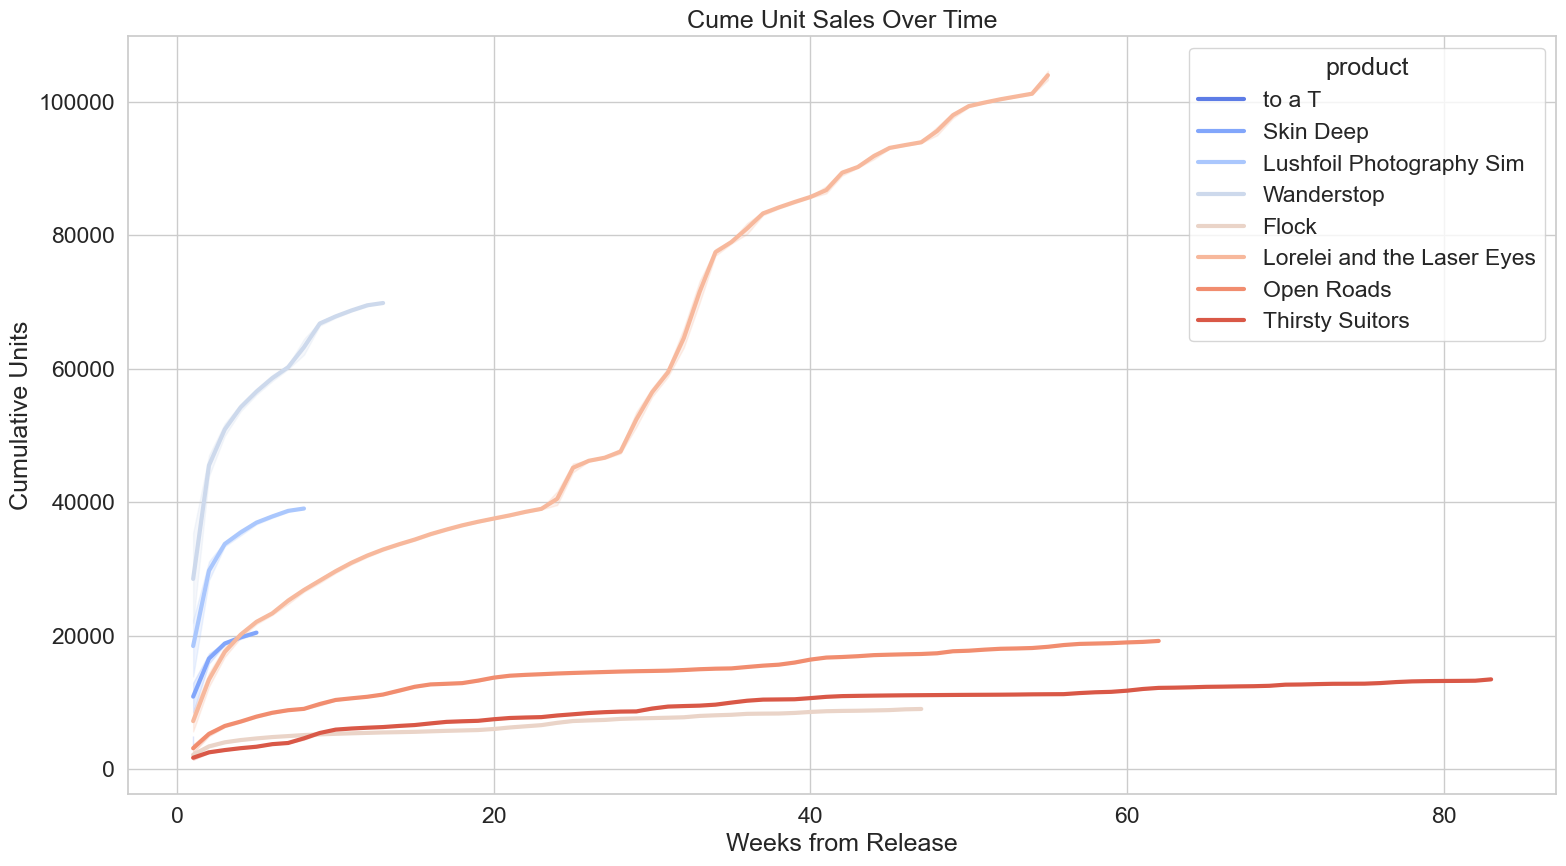

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style for aesthetics
sns.set_theme(style="whitegrid", font_scale=1.5)

# Plot the data
plt.figure(figsize=(16, 9))
sns.lineplot(data=title_df, x="Weeks_from_Release", y="units", hue='product', palette='coolwarm', linewidth=3)
#sns.lineplot(data=stray_custom, x="Weeks_from_Release", y="PlayStation", label='Stray - PS')
#sns.lineplot(data=stray_custom, x="Weeks_from_Release", y="Steam", label='Stray - Steam')


# Adding titles and labels
plt.title("Cume Unit Sales Over Time")
plt.xlabel("Weeks from Release")
plt.ylabel("Cumulative Units")

# Show the plot
plt.tight_layout()
plt.show()

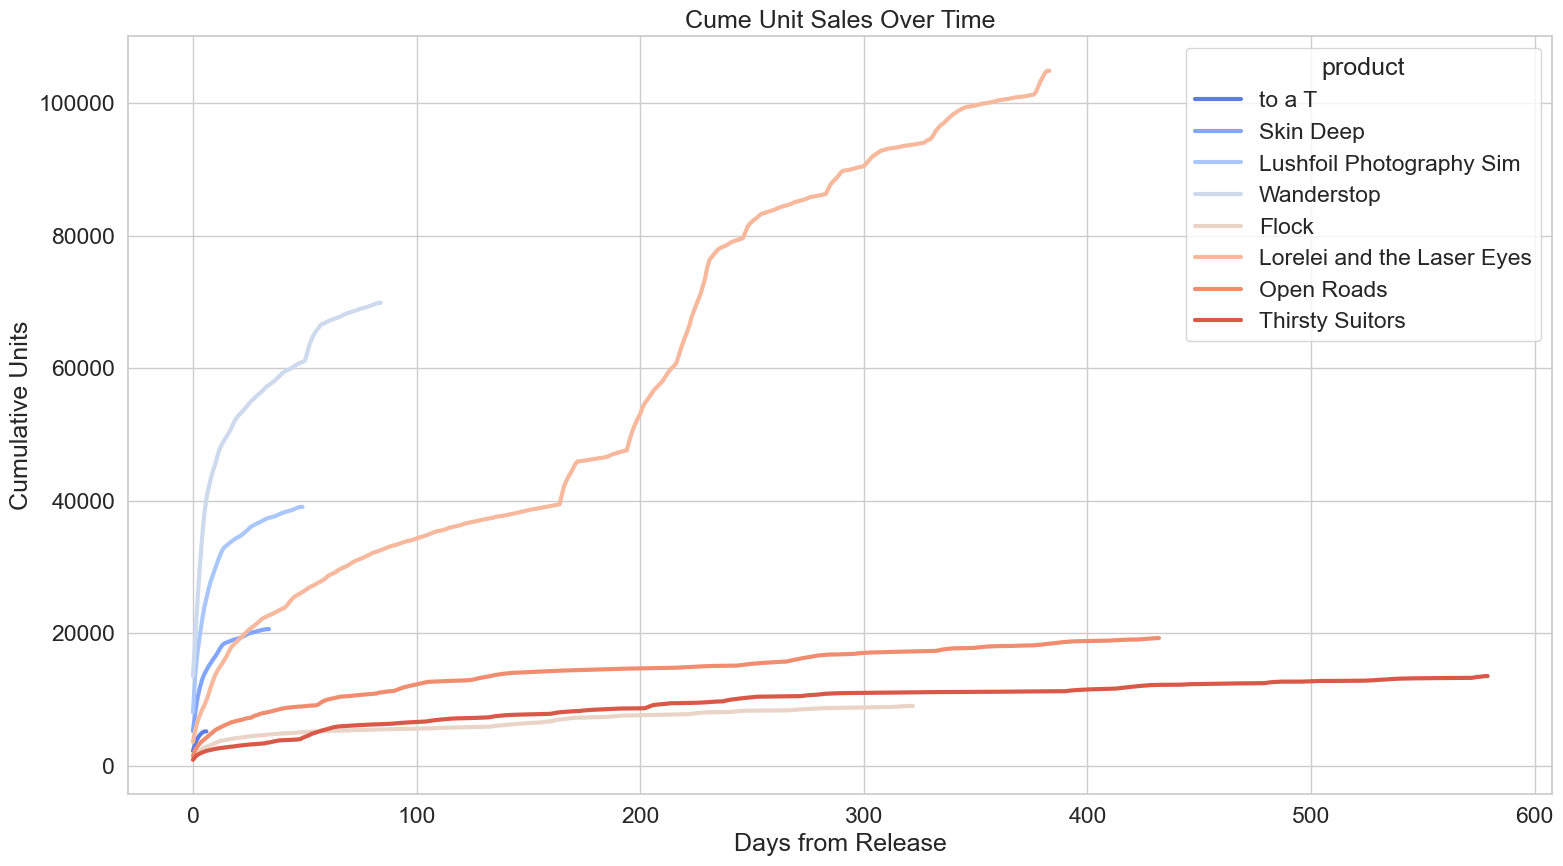

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style for aesthetics
sns.set_theme(style="whitegrid", font_scale=1.5)

# Plot the data
plt.figure(figsize=(16, 9))
sns.lineplot(data=title_df, x="DAR", y="units", hue='product', palette='coolwarm', linewidth=3)
#sns.lineplot(data=stray_custom, x="Weeks_from_Release", y="PlayStation", label='Stray - PS')
#sns.lineplot(data=stray_custom, x="Weeks_from_Release", y="Steam", label='Stray - Steam')


# Adding titles and labels
plt.title("Cume Unit Sales Over Time")
plt.xlabel("Days from Release")
plt.ylabel("Cumulative Units")

# Show the plot
plt.tight_layout()
plt.show()

In [28]:
import plotly.express as px

# Create the interactive line plot
fig = px.line(df, 
              x="Weeks_from_Release", 
              y="percent_of_max", 
              color='product',
              title="Cumulative Units Over Time",
              labels={
                  "Weeks_from_Release": "Weeks from Release",
                  "units": "Cume Units"
              })

# Update the layout for better aesthetics
fig.update_layout(
    autosize=True,
    height=600,
    margin=dict(l=20, r=20, t=50, b=20),
    hovermode='closest'
)

# Save as HTML
fig.write_html("docs/cumulative_units_overtime_100.html")

# Show the interactive plot
fig.show()

In [29]:
title_df['new_units'] = title_df['units'].diff()

In [30]:
ranked_df = df.query("Weeks_from_Release ==1").sort_values(by='units', ascending=False)

In [31]:
range = 0.50

high_end = current_cume * (1 + range)
low_end = current_cume * (1 - range)

In [32]:
low_end

2593.5

In [ ]:
df_filtered = ranked_df[~ranked_df['product'].str.contains('Soundtrack', case=False, na=False)]
df[~df['product'].str.contains('Soundtrack', case=False, na=False)].to_csv("sensitivity.csv")

In [ ]:
df_filtered.query("@low_end < units <@high_end")

In [ ]:
df_filtered['pct_rank'] = df_filtered['units'].rank(pct=True)

In [ ]:
df_filtered

In [ ]:
df_filtered.query("product==@title")

In [ ]:
stop

# Average Sales Price

In [ ]:


# Define folder path
folder_path = "units/cume_units.xlsx"


# Read all files into DataFrames and add filename column
units = pd.read_excel(folder_path, skiprows=2)

units = units.rename({"Cumulative Selected Measure":"units"}, axis=1)

In [ ]:
units

In [ ]:

revs = revs.rename({"Cumulative Selected Measure":"revenue"}, axis=1)

revs

In [ ]:
combined = pd.merge(units, revs, on=["product", 'Date'])

In [ ]:
combined['avg_price'] = combined['revenue'] / combined['units']

In [ ]:
combined.query("product=='Stray'")

In [ ]:
combined.groupby(by='product')[['units', 'revenue', 'avg_price']].max().to_csv("lifetime_units_and_rev.csv")

In [ ]:
combined['release_date'] = pd.to_datetime(combined['Date'])

combined['release_date'] = combined.groupby('product')['release_date'].transform('min')

combined["DAR"] = (combined["Date"] - combined["release_date"]).dt.days
#df_combined["DAR"] = df_combined["DAR"].clip(lower=0)

combined["Weeks_from_Release"] = (combined["DAR"] // 30) + 1  # Week 1 starts at 0-7 days

#df = df.query("0 <= Weeks_from_Release <=12")

combined = combined.query("'1/1/2015' <= release_date <='1/1/2025'")

combined = combined.groupby(["product", "Weeks_from_Release"], as_index=False)["avg_price"].max()

In [ ]:
combined['price_delta'] = combined.groupby('product')['avg_price'].diff()

In [ ]:
import numpy as np

conditions = [
    (combined['Weeks_from_Release'] > 0) & (combined['Weeks_from_Release'] <= 12),   # 1-12 months (first year)
    (combined['Weeks_from_Release'] > 12) & (combined['Weeks_from_Release'] <= 24), # 13-24 months (second year)
    (combined['Weeks_from_Release'] > 24)  # 24+ months (3+ years)
]

choices = ['First Year', 'Second Year', '3+ Years']

combined['TIER'] = np.select(conditions, choices, default='Unknown')  # 'Unknown' if it doesn't fit any condition

In [ ]:
combined.groupby('TIER').avg_price.mean().sort_values()

In [ ]:
combined.groupby('TIER').price_delta.mean().sort_values()